# **KNN**

# What is K-Nearest Neighbors (KNN)?

**K-Nearest Neighbors (KNN)** is a supervised machine learning algorithm that predicts the category or value of a new data point by finding the "K" closest examples in the training data and making a decision based on their majority vote (for classification) or their average (for regression).

In short: Tell me who your closest neighbors are, and I'll tell you who you are.

KNN is one of the simplest, yet most widely used supervised machine learning algorithms. Unlike other algorithms that mathematically "learn" a complex mapping function (like Linear Regression or Neural Networks), KNN is a **"Lazy Learner."** 

It essentially memorizes all of the available training data and makes predictions for new data points based purely on mathematical similarity (distance) to its closest existing neighbors.

### How it works:
When asked to predict the outcome of a brand new, unseen data point, KNN performs the following steps:
1.  **Calculate Distance:** It measures the mathematical distance (usually Euclidean) between the new point and every single point in the entire training dataset.
2.  **Find the Nearest "K":** It identifies the **'K'** data points that are closest to the new point (where 'K' is a number you define, like 5).
3.  **Vote (Classification):** If you are classifying data (e.g., predicting "Dog" or "Cat"), the algorithm looks at the 'K' closest neighbors and takes a majority vote. If 4 of the 5 closest points are Dogs, the new point is predicted as a Dog.
4.  **Average (Regression):** If you are predicting a continuous number (e.g., House Price), the algorithm calculates the average value of those 'K' closest neighbors.

### Key Characteristics:
*   **Lazy Learning (Instance-Based):** It does almost zero actual "training" beforehand. All the heavy computational lifting happens *at the moment of prediction*, making predictions quite slow for massive datasets.
*   **Non-Parametric:** It makes absolutely zero assumptions about the underlying distribution of the data (it doesn't assume the data follows a straight line, a normal curve, etc.). It strictly relies on the raw spatial grouping of the data.
*   **Highly Sensitive to Scale:** Because it actively calculates geometric distances between points, variables with larger numerical ranges (like Income in $100,000s) will completely overpower smaller variables (like Age in decades). Therefore, **Feature Scaling (Standardization/Normalization) is strictly required** before using KNN.


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('brest cancer data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)
print(df.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],test_size=0.2, random_state=2)
X_train.head()

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,15.30,33.17,100.20,706.7,0.1241,0.22640,0.1326,0.10480,0.2250,0.08321
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,...,23.36,32.06,166.40,1688.0,0.1322,0.56010,0.3865,0.17080,0.3193,0.09221
203,13.81,23.75,91.56,597.8,0.13230,0.17680,0.15580,0.09176,0.2251,0.07421,...,19.20,41.85,128.50,1153.0,0.2226,0.52090,0.4646,0.20130,0.4432,0.10860
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,12.84,35.34,87.22,514.0,0.1909,0.26980,0.4023,0.14240,0.2964,0.09606


Lesser number of neighbors is better, but prone to overfitting, and vice versa.

**The maximum number of neighbors is the total number of features in the dataset, causing underfitting.**


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

accuracy_score(y_test, y_pred)

0.9035087719298246

## K-Nearest Neighbors (KNN) Hyper-parameters Explained

The `KNeighborsClassifier` (and Regressor) in `scikit-learn` has several crucial hyper-parameters that control how the algorithm finds neighbors and makes predictions. Tuning these is essential for preventing overfitting and speeding up predictions.

Here is a simple breakdown of every parameter:

### 1. `n_neighbors` (int)
*   **What it does:** This is the "**K**" in KNN. It decides exactly how many neighboring data points the model should look at before voting on a prediction.
*   **Typical Values:** `3`, `5`, `7`, `9` (Odd numbers are preferred in classification to avoid tie-votes).
*   **Impact:** 
    *   **Too Low (e.g., K=1):** The model becomes highly sensitive to noise and outliers. It will perfectly memorize the training data but fail on new data (**High Variance / Overfitting**).
    *   **Too High (e.g., K=100):** The model becomes too rigid and ignores local patterns, completely blurring the decision boundary (**High Bias / Underfitting**).
*   **Default:** `5`

### 2. `weights` (str or callable)
*   **What it does:** Decides *how* the votes of the `n_neighbors` are counted. Does every neighbor get an equal vote, or do closer neighbors get a stronger vote?
*   **Options:**
    *   `'uniform'`: All `K` neighbors have exactly the same voting power, regardless of how far away they are.
    *   `'distance'`: Closer neighbors have a heavier weight (stronger vote) than neighbors that are further away. This is highly recommended if your data points are unevenly spread out.
*   **Default:** `'uniform'`

### 3. `algorithm` (str)
*   **What it does:** KNN is famously slow at prediction time because it distances the new point against *every single point* in the training set. This parameter lets you choose the backend mathematical algorithm used to compute those distances faster.
*   **Options:**
    *   `'brute'`: The brute-force approach. It literally calculates the distance between the new point and every single training point. (Very slow for large datasets).
    *   `'kd_tree'`: Creates a binary tree structure to divide the spatial data. Much faster than brute force for low-dimensional data (under 20 features).
    *   `'ball_tree'`: Similar to kd_tree but creates nested hyperspheres. It is optimized to handle high-dimensional data better than kd_tree.
    *   `'auto'`: Let scikit-learn look at your data and automatically choose the fastest algorithm.
*   **Default:** `'auto'`

### When to use which `algorithm`?

| Algorithm | Dimensionality (Features) | Dataset Size (Rows) | (Pros & Cons) |
| :--- | :--- | :--- | :--- |
| **`brute`** | Very Low (< 10) | Very Small (< 1,000) | **Pros:** Zero "training" time since it doesn't build a complex tree structure before predicting. <br><br>**Cons:** Prediction gets exponentially slower as your dataset grows. It does the heavy math on *every single point*, making it terribly slow for large datasets. |
| **`kd_tree`** | Low to Medium (< 20) | Large (1,000+) | **Pros:** Extremely fast predictions for massive datasets because it cuts the spatial data in half with straight lines (like a binary search). <br><br>**Cons:** Suffers severely from the "Curse of Dimensionality." If you have more than ~20 features, the straight-line cuts lose their efficiency, and the speed drops back down to basically brute-force speeds. |
| **`ball_tree`** | Medium to High (20+) | Large (1,000+) | **Pros:** Beats the `kd_tree` in high-dimensional datasets. It groups points into overlapping hyper-spheres instead of straight-line boxes, which scales significantly better when you have dozens or hundreds of features. <br><br>**Cons:** It takes more time and computational power to build these nested spheres during the initial "training" loop compared to `kd_tree`. |
| **`auto`** | Any | Any | **Pros:** Takes the guesswork out. `scikit-learn` mathematically analyzes your specific dataset size, feature count, and data sparsity to choose the absolute best algorithm from the three above. <br><br>**Cons:** None. This is highly recommended to use 95% of the time. |


### 4. `leaf_size` (int)
*   **What it does:** This parameter only matters if you are using the `'kd_tree'` or `'ball_tree'` algorithms. It determines how many points are left in a "leaf" node of the tree before the algorithm shifts back to doing a brute-force search for that specific subgroup.
*   **Impact:** Modifying this does not change your accuracy at all. It *only* affects the speed and memory usage of the model. 
*   **Default:** `30`

### 5. `p` (int)
*   **What it does:** This parameter controls the exact mathematical formula used to calculate the "distance" between points (the Minkowski distance power parameter).
*   **Options:**
    *   `p = 1`: Uses **Manhattan Distance** (L1 norm). Imagine navigating a city grid; it calculates distance using absolute sums of differences. Great for high-dimensional or sparse data.
    *   `p = 2`: Uses **Euclidean Distance** (L2 norm). The standard "straight-line" mathematical distance. The most common choice.
*   **Default:** `2` (Euclidean)

### 6. `metric` (str)
*   **What it does:** The specific string identifier for the distance metric to use. By default, it is set to `'minkowski'`, which, when combined with `p=2`, mathematically resolves to the standard Euclidean distance. 
*   **Default:** `'minkowski'`

### 7. `n_jobs` (int)
*   **What it does:** Because KNN prediction involves thousands of heavy math calculations, you can tell scikit-learn to use multiple CPU cores to process the distances in parallel.
*   **Options:**
    *   `None`: Uses 1 core.
    *   `-1`: Forces scikit-learn to use *all* available CPU cores on your machine, drastically speeding up the search process on large datasets.
*   **Default:** `None`


There are two ways to find the required number of `K` in the dataset:
1. Heustric method
2. Experimentation method 

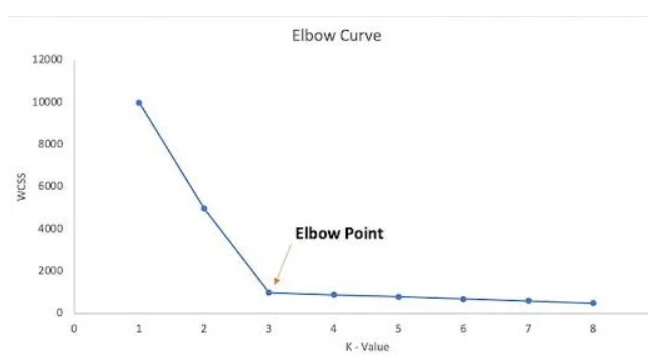

### 1. Heuristic Method (The Elbow Method)

The **Elbow Method** is a heuristic used to determine the optimal number of clusters by calculating the **Within-Cluster Sum of Squares (WCSS)** for different values of $K$.

*   **WCSS (Inertia):** Measures the sum of squared distances between each data point and its assigned cluster centroid.
*   **The "Elbow":** We plot $K$ against WCSS and look for the "elbow" point where the rate of decrease significantly slows down. This point represents the optimal balance between cluster compactness and the number of clusters.

- Bascially it is done by doing the `square root of number of features`, but make sure that if you get any even number as the square root, then make it an odd number by either adding or subtracting 1. 

### 2. Experimentation Method (The Silhouette Method)

Bascially here you find the optimal number of clusters by experimenting on every number of clusters and then finding the one that has the highest accuracy score.

The **Silhouette Method** is used to validate the consistency within clusters of data. It provides a succinct graphical representation of how well each object has been classified.

*   **Silhouette Score:** The score ranges from -1 to +1. 
    *   **+1:** Indicates that the sample is far away from the neighboring clusters (well-clustered).
    *   **0:** Indicates that the sample is on or very close to the decision boundary between two neighboring clusters.
    *   **-1:** Indicates that those samples might have been assigned to the wrong cluster.

*   **The Calculation:** For a data point $i$, the silhouette coefficient $s(i)$ is defined as:
    $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
    *   $a(i)$: The average distance between $i$ and all other points in the same cluster (Cohesion).
    *   $b(i)$: The average distance between $i$ and all points in the nearest cluster that $i$ is not a part of (Separation).

*   **Optimal K:** We determine the optimal number of clusters by picking the $K$ that yields the maximum average silhouette score. Unlike the Elbow Method, which looks for a "bend," the Silhouette Method looks for the highest peak.

### Checking for accuracy on different clusters

In [5]:
scores = []
max_accuracy = 0

for i in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Calculate once and store
    current_accuracy = np.round(accuracy_score(y_test, y_pred), 2)
    scores.append(current_accuracy)

    # Update and print only if accuracy improves
    if current_accuracy > max_accuracy:
        max_accuracy = current_accuracy
        print(f"Neighbors: {i} | Accuracy: {current_accuracy}")

print(f"\n\nMax accuracy: {max(scores)} at index {scores.index(max(scores))}")

# as you can see the highest accuracy is at neighbours 7

Neighbors: 1 | Accuracy: 0.89
Neighbors: 3 | Accuracy: 0.9
Neighbors: 5 | Accuracy: 0.91
Neighbors: 6 | Accuracy: 0.92
Neighbors: 7 | Accuracy: 0.93


Max accuracy: 0.93 at index 6


In [6]:
scores

[np.float64(0.89),
 np.float64(0.89),
 np.float64(0.9),
 np.float64(0.89),
 np.float64(0.91),
 np.float64(0.92),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93)]

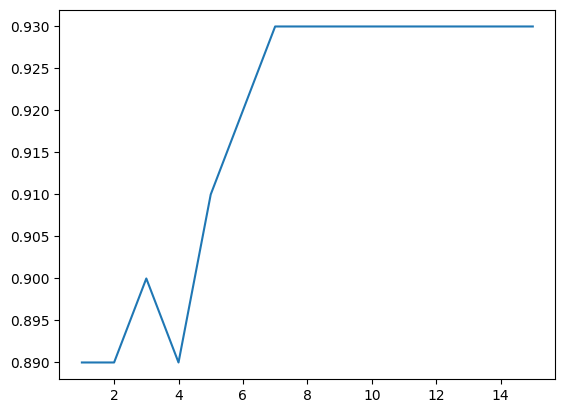

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),scores)


### Limitations of K-Nearest Neighbors (KNN)

1. **Computational Complexity (Lazy Learning):**
   - KNN is a "lazy learner," meaning it performs no explicit training phase. All computation happens during prediction.
      - In simple words, in training phase it just stores the data points, and during prediction it calculates the distance between the new data point and all the stored data points.
      - The training might be fast, but the prediction will definitely be slow, if it is a very large data set.
   - Prediction time complexity is $O(n \cdot d)$, where $n$ is the number of samples and $d$ is the number of dimensions. This makes it extremely slow for large datasets.

2. **High Memory Usage:**
   - The algorithm must store the entire training dataset in memory to calculate distances for every new query point.

3. **Sensitivity to Feature Scaling:**
   - Since KNN relies on distance metrics (e.g., Euclidean distance), features with larger scales will disproportionately influence the results. Feature scaling (Standardization or Normalization) is strictly required.

4. **Curse of Dimensionality:**
   - In high-dimensional spaces, the distance between points becomes less meaningful as the volume of the space increases exponentially. This often leads to overfitting and degraded performance unless dimensionality reduction (e.g., PCA) is applied.

5. **Sensitivity to Noise and Outliers:**
   - A single outlier can significantly affect the prediction, especially when the value of $K$ is small.

6. **Imbalanced Data Bias:**
   - If one class has a significantly higher frequency than others, it will naturally dominate the "neighborhood" of most query points, leading to biased classifications towards the majority class.

7. **Optimal K Selection:**
   - Choosing the right value for $K$ is non-trivial. A small $K$ makes the model sensitive to noise (high variance), while a large $K$ makes the boundaries less distinct (high bias). Finding the balance requires exhaustive cross-validation.



# The Difference Between KNN and K-Means

Although both algorithms have a "**K**" in their name and rely on **distance calculations** (like Euclidean distance) to work, they are completely different algorithms used for entirely different purposes in Machine Learning.

The fundamental difference lies in their learning type: **KNN is for Supervised Learning**, while **K-Means is for Unsupervised Learning**.



### 1. KNN (K-Nearest Neighbors)
*   **Type:** Supervised Learning (Classification & Regression)
*   **Goal:** Predict the label (or value) of a **new, unknown data point** based on the data you already have.
*   **Intuition:** *"Tell me who your neighbors are, and I'll tell you who you are."*
*   **What does 'K' mean?:** $\mathbf{K}$ represents the **number of nearest data points (neighbors)** the algorithm looks at to make its decision.
    *   *Example:* If you want to predict if an email is "Spam" or "Not Spam," and you set $K=5$, the algorithm looks at the 5 emails that are mathematically "closest" to the new email. If 4 are Spam and 1 is Not Spam, the new email is classified as Spam (majority voting).
*   **Training:* KNN is often called a "lazy learner" because it technically doesn't "train" a model in advance; it just memorizes the dataset and does all the math at the exact moment a prediction is asked for.

### 2. K-Means (K-Means Clustering)
*   **Type:** Unsupervised Learning (Clustering)
*   **Goal:** Group **unlabeled data** into separate buckets (clusters) based on their similarities. There are no right or wrong answers (no target variable $y$).
*   **Intuition:** *"Find the center mass of similar items and pull them together into groups."*
*   **What does 'K' mean?:** $\mathbf{K}$ represents the **number of clusters (groups)** you want the algorithm to divide your entire dataset into.
    *   *Example:* You have a list of of 10,000 customers, but you don't know anything about their buying habits. You set $K=3$. The algorithm will mathematically group them into 3 distinct segments (e.g., it might naturally discover clusters for "Bargain Hunters," "Luxury Buyers," and "Occasional Shoppers").
*   **Training:* K-Means is an iterative algorithm. It randomly drops $K$ center points (centroids) into the data, assigns points to the nearest centroid, moves the centroid to the middle of those points, and repeats until the groups stop changing.



### Quick Comparison Table

| Feature | K-Nearest Neighbors (KNN) | K-Means Clustering |
| :--- | :--- | :--- |
| **Learning Type** | Supervised | Unsupervised |
| **Data Requirement** | Labeled Data (Needs both $X$ and $y$) | Unlabeled Data (Only needs $X$) |
| **Primary Objective** | Categorize or predict a value for new data | Discover hidden patterns and group existing data |
| **Meaning of 'K'** | Number of Nearest Neighbors | Number of Clusters/Groups |
| **Output Type** | A label (Class A, Class B) or a number | A cluster assignment (Group 1, Group 2) |
| **Algorithm Nature** | "Lazy" (Waits for a prediction request before computing) | Iterative (Computes centers until they stabilize) |



### Simple Analogy
*   **KNN Strategy:** You walk into a party and don't know what language to speak. You listen to the **3 people closest to you** ($K=3$) and hear they are speaking Spanish. You decide to speak Spanish too.
*   **K-Means Strategy:** You have a massive pile of assorted, unsorted LEGOs on the floor. You decide you want to organize them into **4 separate boxes** ($K=4$). You let the algorithm sort them based on similarities (it might end up grouping them by Color, Shape, or Size).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…